# 02 — Information Extraction

This notebook analyzes the information extraction part of the project.

The project extracts structured knowledge from scientific titles and abstracts. These outputs are later used to build a knowledge graph.

## Goals

- Load processed scientific documents.
- Extract named entities.
- Extract TF-IDF keywords.
- Extract simple co-occurrence relations.
- Save extraction outputs for inspection and graph construction.

In [5]:
from pathlib import Path
import sys

current = Path.cwd().resolve()

for candidate in [current, *current.parents]:
    if (candidate / "src").exists() and (candidate / "config.yaml").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find project root")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform


In [6]:
import matplotlib.pyplot as plt
import pandas as pd

from src.utils.common import (
    display_basic_frame_info,
    load_or_create_processed_documents,
    save_table,
    setup_notebook,
)

CONFIG, PATHS = setup_notebook()

Project root: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform
Config: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\config.yaml
Raw data: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\raw
Processed data: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed
Graphs: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\graphs
Figures: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\reports\figures


## Load processed documents

In [8]:
df = load_or_create_processed_documents(CONFIG, PATHS)

display_basic_frame_info(df, "Processed documents")

Loading processed documents from: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed\processed_documents.csv
Processed documents shape: (5000, 9)
Processed documents columns: ['doc_id', 'title', 'abstract', 'authors', 'categories', 'date', 'text', 'cleaned_text', 'tokens']


,doc_id,title,abstract,authors,categories,date,text,cleaned_text,tokens
0,1804.05499,Community Member Retrieval on Social Media usi...,This paper addresses the problem of communit...,"['Aaron Jaech', 'Shobhit Hathi', 'Mari Ostendo...",['cs.CL'],2018-04-17,Community Member Retrieval on Social Media usi...,community member retrieval social medium textu...,community member retrieval social medium textu...
1,2310.12815,Formalizing and Benchmarking Prompt Injection ...,A prompt injection attack aims to inject malic...,"['Yupei Liu', 'Yuqi Jia', 'Runpeng Geng', 'Jin...","['cs.CR', 'cs.AI', 'cs.CL', 'cs.LG']",2025-11-13,Formalizing and Benchmarking Prompt Injection ...,formalizing benchmarke prompt injection attack...,formalizing benchmarke prompt injection attack...
2,2303.12728,LocalEyenet: Deep Attention framework for Loca...,Development of human machine interface has b...,"['Somsukla Maiti', 'Akshansh Gupta']","['cs.CV', 'cs.LG']",2023-03-23,LocalEyenet: Deep Attention framework for Loca...,localeyenet deep attention framework localizat...,localeyenet deep attention framework localizat...
3,2012.12469,Augmenting Policy Learning with Routines Disco...,Humans can abstract prior knowledge from ver...,"['Zelin Zhao', 'Chuang Gan', 'Jiajun Wu', 'Xia...","['cs.LG', 'cs.AI', 'cs.SC']",2021-05-04,Augmenting Policy Learning with Routines Disco...,augment policy learning routine discover singl...,augment policy learning routine discover singl...
4,2601.10421,Are Language Models Models?,"Futrell and Mahowald claim LMs ""serve as model...",['Philip Resnik'],"['cs.CL', 'cs.AI']",2026-01-16,Are Language Models Models?. Futrell and Mahow...,language model model futrell mahowald claim se...,language model model futrell mahowald claim se...


## Prepare text corpus

In [9]:
texts = df["text"].fillna("").astype(str).tolist()
doc_ids = df["doc_id"].astype(str).tolist()

print("Number of documents:", len(texts))
print("First document preview:")
print(texts[0][:1000])

Number of documents: 5000
First document preview:
Community Member Retrieval on Social Media using Textual Information.   This paper addresses the problem of community membership detection using only
text features in a scenario where a small number of positive labeled examples
defines the community. The solution introduces an unsupervised proxy task for
learning user embeddings: user re-identification. Experiments with 16 different
communities show that the resulting embeddings are more effective for community
membership identification than common unsupervised representations.


## Configure extraction modules

In [10]:
extraction_cfg = CONFIG.get("extraction", {})

spacy_model = extraction_cfg.get("spacy_model", "en_core_web_sm")
entity_types = extraction_cfg.get("entity_types")
keyword_top_n = extraction_cfg.get("keyword_top_n", 10)
relation_window = extraction_cfg.get("relation_window", 1)

print("spaCy model:", spacy_model)
print("Entity types:", entity_types)
print("Keyword top_n:", keyword_top_n)
print("Relation window:", relation_window)

spaCy model: en_core_web_sm
Entity types: ['ORG', 'PERSON', 'GPE', 'PRODUCT', 'WORK_OF_ART']
Keyword top_n: 10
Relation window: 1


## Named Entity Recognition

In [11]:
from src.extraction.entity_extraction import EntityExtractor

entity_extractor = EntityExtractor(
    spacy_model=spacy_model,
    entity_types=entity_types,
)

doc_entities = entity_extractor.extract_batch(texts)

entity_rows = []

for doc_id, entities in zip(doc_ids, doc_entities):
    for entity in entities:
        entity_rows.append(
            {
                "doc_id": doc_id,
                "entity": entity.text,
                "label": entity.label,
                "start": entity.start,
                "end": entity.end,
            }
        )

entities_df = pd.DataFrame(entity_rows)

display(entities_df.head(20))
print("Extracted entity rows:", len(entities_df))

,doc_id,entity,label,start,end
0,1804.05499,Community,ORG,0,9
1,1804.05499,Social Media,ORG,30,42
2,1804.05499,Textual Information,ORG,49,68
3,2310.12815,Defenses,GPE,58,66
4,2310.12815,LLM-Integrated Application,ORG,157,183
5,2303.12728,Localization of Eyes,ORG,42,62
6,2303.12728,LocalEyenet,ORG,707,718
7,2012.12469,Single\n Demonstration,ORG,59,81
8,2012.12469,Atari,ORG,954,959
9,2012.12469,A2C. Further,PERSON,1083,1095


Extracted entity rows: 18494


## Entity type distribution

,label,count
0,ORG,13256
1,PERSON,3027
2,GPE,1361
3,PRODUCT,516
4,WORK_OF_ART,334


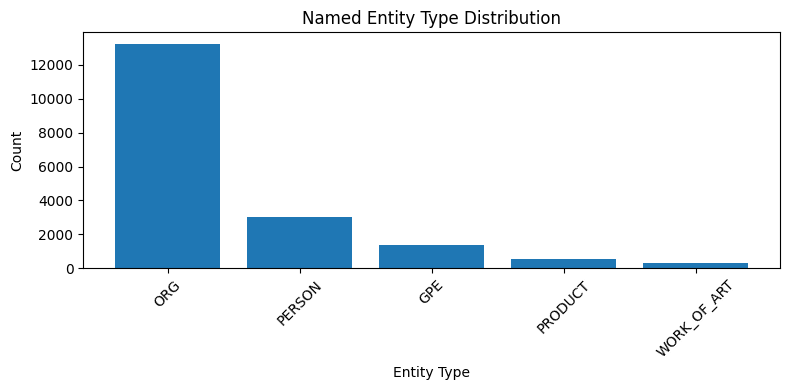

In [12]:
if entities_df.empty:
    print("No entities extracted.")
else:
    entity_counts = entities_df["label"].value_counts().reset_index()
    entity_counts.columns = ["label", "count"]

    display(entity_counts)

    plt.figure(figsize=(8, 4))
    plt.bar(entity_counts["label"], entity_counts["count"])
    plt.title("Named Entity Type Distribution")
    plt.xlabel("Entity Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## TF-IDF keyword extraction

In [13]:
from src.extraction.keyword_extraction import TfidfKeywordExtractor

cleaned_texts = df["cleaned_text"].fillna("").astype(str).tolist()

keyword_extractor = TfidfKeywordExtractor(top_n=keyword_top_n)
keyword_extractor.fit(cleaned_texts)

keyword_rows = []

for index, doc_id in enumerate(doc_ids):
    for keyword, score in keyword_extractor.get_keywords(index):
        keyword_rows.append(
            {
                "doc_id": doc_id,
                "keyword": keyword,
                "score": float(score),
            }
        )

keywords_df = pd.DataFrame(keyword_rows)

display(keywords_df.head(20))
print("Extracted keyword rows:", len(keywords_df))

,doc_id,keyword,score
0,1804.05499,community,0.543833
1,1804.05499,membership,0.308435
2,1804.05499,identification,0.226954
3,1804.05499,unsupervised,0.223724
4,1804.05499,embedding,0.209118
5,1804.05499,label example,0.176653
6,1804.05499,textual information,0.172189
7,1804.05499,information paper,0.165145
8,1804.05499,user,0.162825
9,1804.05499,experiment different,0.159681


Extracted keyword rows: 49993


## Most frequent keywords

,keyword,frequency,avg_score
3964,llm,292,0.197192
2943,graph,204,0.244917
4401,model,203,0.156403
3234,image,190,0.219648
173,agent,168,0.256624
4709,network,168,0.194536
3707,language,155,0.200373
1593,datum,145,0.166473
5888,reasoning,143,0.239585
221,algorithm,141,0.179129


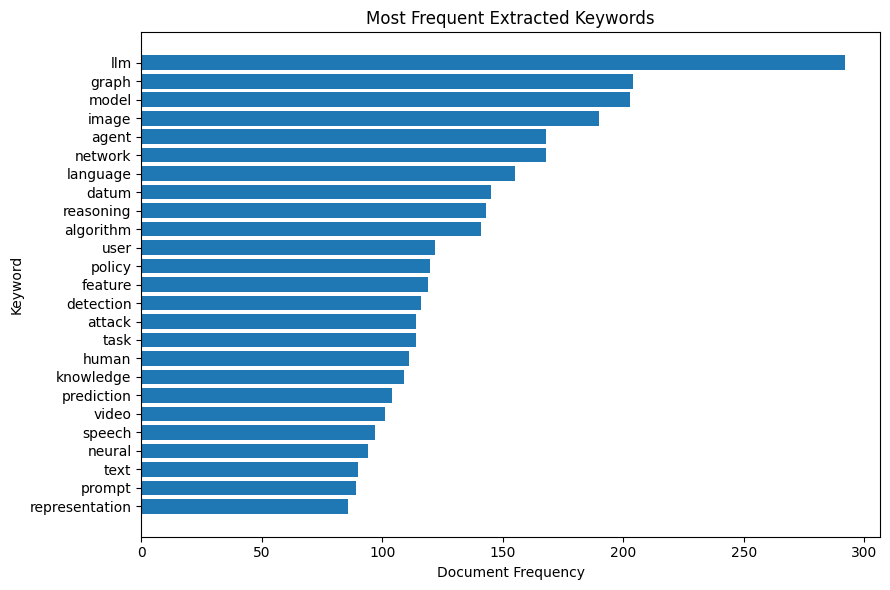

In [14]:
if keywords_df.empty:
    print("No keywords extracted.")
else:
    top_keywords = (
        keywords_df.groupby("keyword", as_index=False)
        .agg(frequency=("doc_id", "count"), avg_score=("score", "mean"))
        .sort_values(["frequency", "avg_score"], ascending=False)
        .head(25)
    )

    display(top_keywords)

    plot_data = top_keywords.sort_values("frequency")

    plt.figure(figsize=(9, 6))
    plt.barh(plot_data["keyword"], plot_data["frequency"])
    plt.title("Most Frequent Extracted Keywords")
    plt.xlabel("Document Frequency")
    plt.ylabel("Keyword")
    plt.tight_layout()
    plt.show()

## Co-occurrence relation extraction

In [15]:
from src.extraction.relation_extraction import (
    CooccurrenceRelationExtractor,
    aggregate_relations,
)

relation_extractor = CooccurrenceRelationExtractor(
    spacy_model=spacy_model,
    window=relation_window,
)

all_relations = []
relation_rows = []

for doc_id, text, entities in zip(doc_ids, texts, doc_entities):
    relations = relation_extractor.extract(text, entities)
    all_relations.extend(relations)

    for relation in relations:
        relation_rows.append(
            {
                "doc_id": doc_id,
                "source": relation.source,
                "relation": relation.relation,
                "target": relation.target,
                "weight": relation.weight,
            }
        )

relations_df = pd.DataFrame(relation_rows)

display(relations_df.head(20))
print("Extracted relation rows:", len(relations_df))

,doc_id,source,relation,target,weight
0,1804.05499,Community,RELATED_TO,Social Media,1
1,1804.05499,Community,RELATED_TO,Textual Information,1
2,1804.05499,Social Media,RELATED_TO,Textual Information,1
3,2303.12728,LocalEyenet,RELATED_TO,Localization of Eyes,1
4,2012.12469,A2C. Further,RELATED_TO,Atari,1
5,2012.12469,A2C. Further,RELATED_TO,CoinRun,1
6,2012.12469,Atari,RELATED_TO,CoinRun,1
7,2601.10421,Futrell,RELATED_TO,Mahowald,1
8,2601.10421,Futrell,RELATED_TO,Marr,1
9,2601.10421,Mahowald,RELATED_TO,Marr,1


Extracted relation rows: 16811


## Aggregated relations

In [16]:
aggregated_relations = aggregate_relations(all_relations)

aggregated_df = pd.DataFrame(
    [
        {
            "source": relation.source,
            "relation": relation.relation,
            "target": relation.target,
            "weight": relation.weight,
        }
        for relation in aggregated_relations
    ]
)

if aggregated_df.empty:
    print("No aggregated relations available.")
else:
    display(aggregated_df.sort_values("weight", ascending=False).head(25))

,source,relation,target,weight
0,AI,RELATED_TO,LLM,49
1,LLM,RELATED_TO,Large Language Models,43
2,RL,RELATED_TO,Reinforcement Learning,29
3,FL,RELATED_TO,Federated Learning,26
4,GNN,RELATED_TO,Graph Neural Networks,23
5,GUI,RELATED_TO,UI,20
6,AI,RELATED_TO,ML,19
7,ML,RELATED_TO,Machine Learning,17
8,FL,RELATED_TO,Federated,17
9,COVID-19,RELATED_TO,CT,14


## Save extraction outputs

In [17]:
save_table(entities_df, PATHS.data_processed / "notebook_entities.csv")
save_table(keywords_df, PATHS.data_processed / "notebook_keywords.csv")
save_table(relations_df, PATHS.data_processed / "notebook_relations.csv")
save_table(aggregated_df, PATHS.data_processed / "notebook_aggregated_relations.csv")

print("Saved extraction outputs to data/processed.")

Saved extraction outputs to data/processed.
